<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Means Clustering**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/movies_metadata.csv')
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [ ]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

In [ ]:
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df = df.reset_index(drop=True)

df['title'] = df['title'].str.lower()

indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['tags'])

In [ ]:
from scipy.sparse import hstack

df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X_num = df[['vote_average','popularity']].values

X = hstack((tfidf_matrix, X_num))
X = X.tocsr()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['tags'])

# Numeric features
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X_num = df[['vote_average','popularity']].values

# Combine
X = hstack((tfidf_matrix, X_num))

# IMPORTANT
X = X.tocsr()

In [ ]:
X_dense = X.toarray()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_reduced = pca.fit_transform(X_dense)

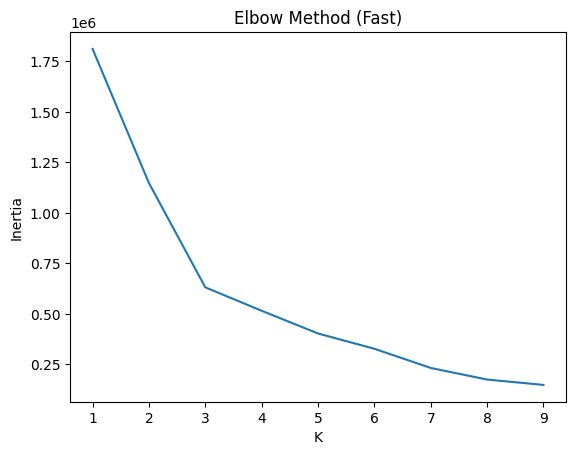

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_reduced)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(range(1, 10), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method (Fast)")
plt.show()

In [ ]:
k = 15

kmeans = KMeans(n_clusters=k, random_state=42)

df['cluster'] = kmeans.fit_predict(X_reduced)

print("Clustering Done ✅")

Clustering Done ✅


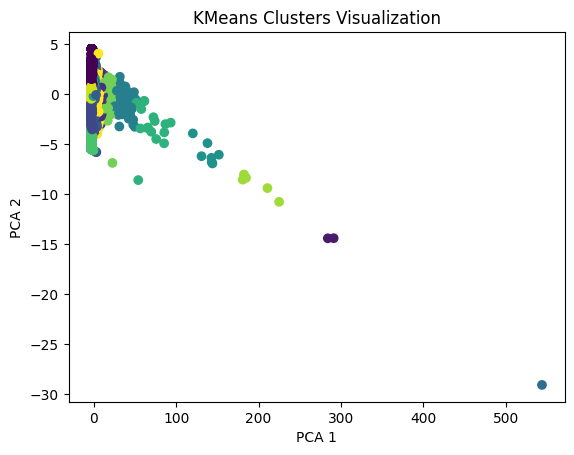

In [ ]:
plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=df['cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clusters Visualization")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Scores
sil_score = silhouette_score(X_reduced, df['cluster'])
db_score = davies_bouldin_score(X_reduced, df['cluster'])
ch_score = calinski_harabasz_score(X_reduced, df['cluster'])

print("=== KMEANS EVALUATION ===")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)
print("Calinski-Harabasz Score:", ch_score)

=== KMEANS EVALUATION ===
Silhouette Score: 0.37145993615210465
Davies-Bouldin Score: 0.5956979970250693
Calinski-Harabasz Score: 92615.99356147749


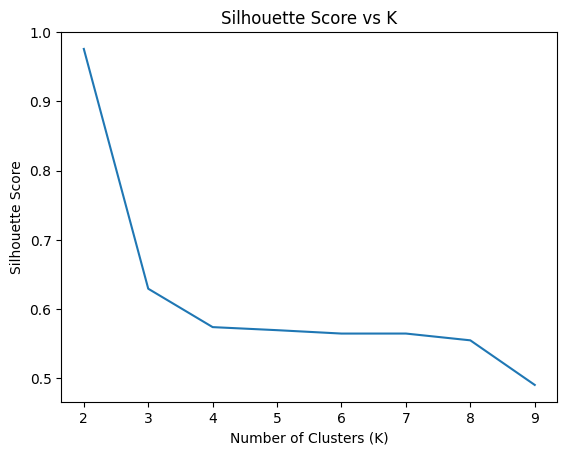

In [ ]:
sil_scores = []

for i in range(2, 10):
    km = KMeans(n_clusters=i, random_state=42)
    labels = km.fit_predict(X_reduced)
    sil_scores.append(silhouette_score(X_reduced, labels))

plt.figure()
plt.plot(range(2, 10), sil_scores)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

In [ ]:
# ensure lowercase mapping
df['title'] = df['title'].str.lower()
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend_kmeans(movie_name, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "❌ Movie not found"

    idx = indices[movie_name]

    cluster = df.iloc[idx]['cluster']

    cluster_movies = df[df['cluster'] == cluster]

    cluster_movies = cluster_movies[cluster_movies['title'] != movie_name]

    cluster_movies = cluster_movies.sort_values(
        by=['vote_average','popularity'],
        ascending=False
    )

    recommendations = cluster_movies['title'].head(top_n).values

    print(f"\n🎬 Input Movie: {movie_name}")
    print(f"📦 Cluster: {cluster}")
    print("\n🔥 Recommended Movies:\n")

    for i, movie in enumerate(recommendations, 1):
        print(f"{i}. {movie}")

In [ ]:
movie = input("Enter movie name: ").lower()
recommend_kmeans(movie)

Enter movie name: Toy Story

🎬 Input Movie: toy story
📦 Cluster: 11

🔥 Recommended Movies:

1. black mirror: white christmas
2. in a heartbeat
3. a dog's will
4. leon: the professional
5. the green mile
6. the empire strikes back
7. american history x
8. rear window
9. princess mononoke
10. 12 angry men
